In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/business_data.csv')
df.head()

,date,region,category,product,units_sold,unit_price,unit_cost,customer_type
0,2025-01-05,South,Electronics,Notebook,3,3500,2800,Corporate
1,2025-01-08,East,Electronics,Mouse,15,80,35,Individual
2,2025-01-12,North,Furniture,Desk,2,1200,750,Corporate
3,2025-01-15,West,Electronics,Monitor,4,1100,700,Individual
4,2025-01-18,South,Furniture,Chair,6,450,220,Corporate


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   date           30 non-null     str  
 1   region         30 non-null     str  
 2   category       30 non-null     str  
 3   product        30 non-null     str  
 4   units_sold     30 non-null     int64
 5   unit_price     30 non-null     int64
 6   unit_cost      30 non-null     int64
 7   customer_type  30 non-null     str  
dtypes: int64(3), str(5)
memory usage: 2.0 KB


In [4]:
df.describe()

,units_sold,unit_price,unit_cost
count,30.000000,30.000000,30.00000
mean,7.466667,1090.000000,767.50000
std,6.699116,1177.285012,966.81021
min,1.000000,80.000000,35.00000
25%,2.000000,150.000000,70.00000
50%,5.000000,775.000000,460.00000
75%,10.000000,1200.000000,750.00000
max,25.000000,3500.000000,2800.00000


In [5]:
df.isnull().sum()

date             0
region           0
category         0
product          0
units_sold       0
unit_price       0
unit_cost        0
customer_type    0
dtype: int64

In [6]:
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,region,category,product,units_sold,unit_price,unit_cost,customer_type
0,2025-01-05,South,Electronics,Notebook,3,3500,2800,Corporate
1,2025-01-08,East,Electronics,Mouse,15,80,35,Individual
2,2025-01-12,North,Furniture,Desk,2,1200,750,Corporate
3,2025-01-15,West,Electronics,Monitor,4,1100,700,Individual
4,2025-01-18,South,Furniture,Chair,6,450,220,Corporate


In [7]:
df['revenue'] = df['units_sold'] * df['unit_price']
df['cost'] = df['units_sold'] * df['unit_cost']
df['profit'] = df['revenue'] - df['cost']
df.head()

,date,region,category,product,units_sold,unit_price,unit_cost,customer_type,revenue,cost,profit
0,2025-01-05,South,Electronics,Notebook,3,3500,2800,Corporate,10500,8400,2100
1,2025-01-08,East,Electronics,Mouse,15,80,35,Individual,1200,525,675
2,2025-01-12,North,Furniture,Desk,2,1200,750,Corporate,2400,1500,900
3,2025-01-15,West,Electronics,Monitor,4,1100,700,Individual,4400,2800,1600
4,2025-01-18,South,Furniture,Chair,6,450,220,Corporate,2700,1320,1380


In [8]:
total_revenue = df['revenue'].sum()
total_profit = df['profit'].sum()
total_units = df['units_sold'].sum()

print(f'Total Revenue: ${total_revenue:,.2f}')
print(f'Total Profit: ${total_profit:,.2f}')
print(f'Total Units Sold: {total_units}')

Total Revenue: $97,650.00
Total Profit: $36,110.00
Total Units Sold: 224


In [9]:
revenue_by_region = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
revenue_by_region


region
South    40800
North    22610
East     19550
West     14690
Name: revenue, dtype: int64

In [10]:
profit_by_category = df.groupby('category')['profit'].sum().sort_values(ascending=False)
profit_by_category

category
Electronics    22160
Furniture      13950
Name: profit, dtype: int64

In [11]:
top_products = df.groupby('product')['revenue'].sum().sort_values(ascending=False)
top_products

product
Notebook    31500
Monitor     22000
Chair       20250
Desk         9600
Mouse        8000
Keyboard     6300
Name: revenue, dtype: int64

In [12]:
revenue_by_customer = df.groupby('customer_type')['revenue'].sum().sort_values(ascending=False)
revenue_by_customer

customer_type
Corporate     64100
Individual    33550
Name: revenue, dtype: int64

In [13]:
df['month'] = df['date'].dt.to_period('M')
df[['date', 'month']].head()

,date,month
0,2025-01-05,2025-01
1,2025-01-08,2025-01
2,2025-01-12,2025-01
3,2025-01-15,2025-01
4,2025-01-18,2025-01


In [14]:
df['month'] = df['date'].dt.to_period('M')
df[['date', 'month']].head()

,date,month
0,2025-01-05,2025-01
1,2025-01-08,2025-01
2,2025-01-12,2025-01
3,2025-01-15,2025-01
4,2025-01-18,2025-01


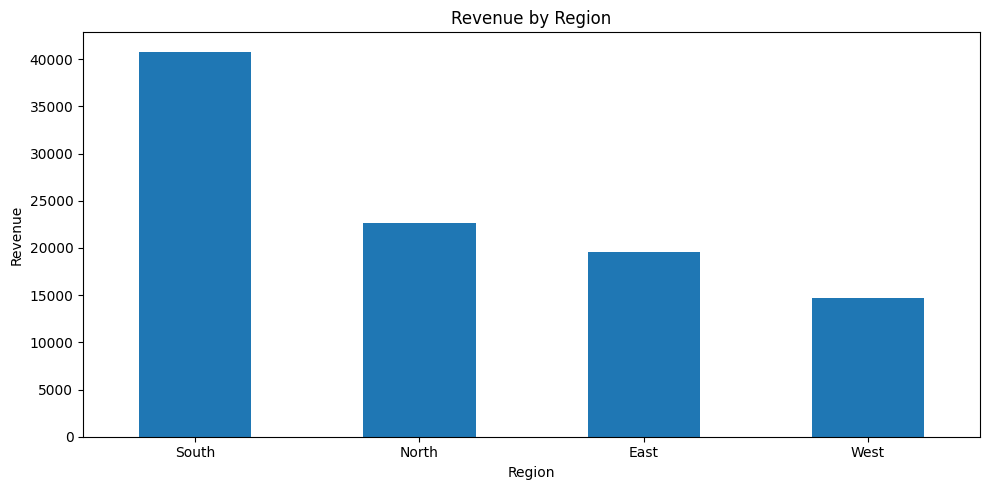

In [15]:
revenue_by_region.plot(kind='bar', figsize=(10,5))
plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/revenue_by_region.png')
plt.show()

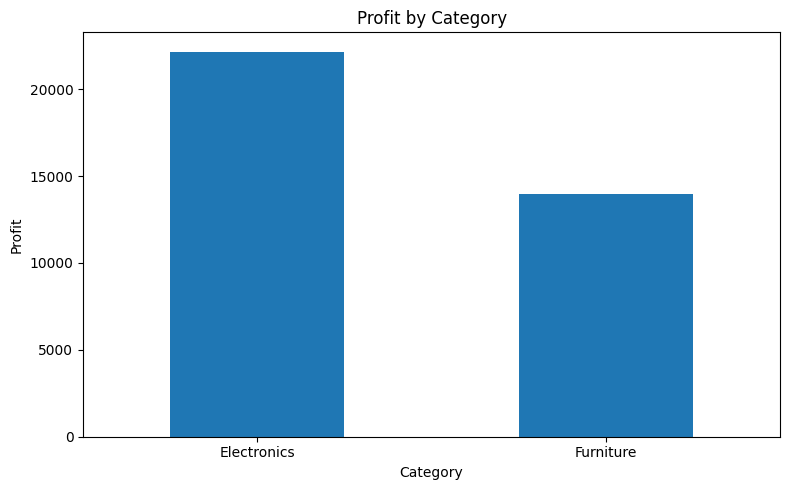

In [16]:
profit_by_category.plot(kind='bar', figsize=(8,5))
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/profit_by_category.png')
plt.show()

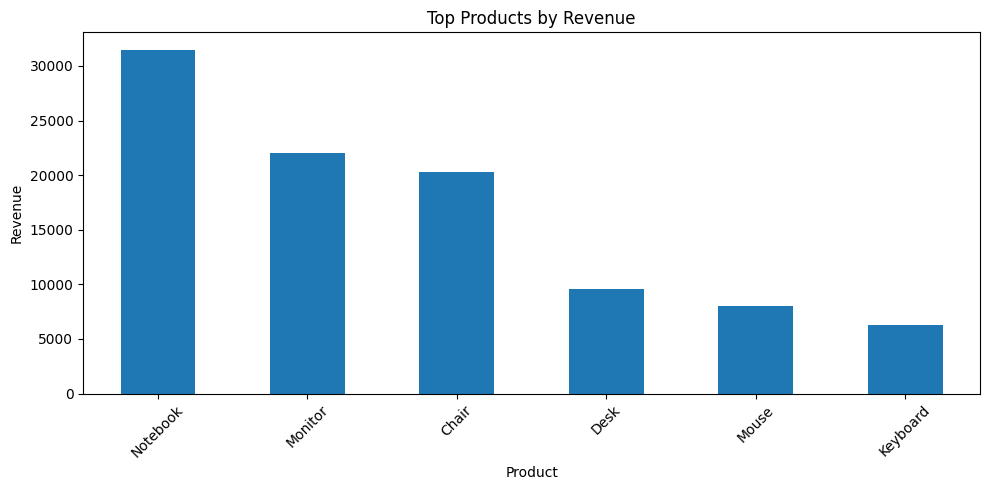

In [17]:
top_products.plot(kind='bar', figsize=(10,5))
plt.title('Top Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/top_products.png')
plt.show()

In [18]:
monthly_revenue.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.tight_layout()
plt.savefig('../images/monthly_revenue.png')
plt.show()

NameError: name 'monthly_revenue' is not defined

## Key Insights

### Revenue Performance

The South region showed strong revenue performance across the analyzed period.

Notebook and Monitor were among the most important products in total revenue generation, showing that premium electronics had a strong impact on business results.

### Profitability

The Electronics category generated the highest profit compared to Furniture.

This suggests that high-value products were the main profit drivers of the business.

### Customer Analysis

Corporate customers contributed significantly to total revenue, especially in premium products such as notebooks, desks, and monitors.

This indicates that business clients may be an important strategic segment.

### Monthly Trend

Revenue varied over the months, showing different performance levels during the first half of the year.

Tracking monthly revenue is essential for identifying seasonality and supporting business decisions.

In [19]:
monthly_revenue.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.tight_layout()
plt.savefig('../images/monthly_revenue.png')
plt.show()

NameError: name 'monthly_revenue' is not defined